In [1]:
from pathlib import Path
import hashlib
import xml.etree.ElementTree as ET
import pandas as pd

PROJECT_ROOT = Path.home() / "cocoa_research"

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "karaagroai"

print("Project:", PROJECT_ROOT)
print("Raw dataset:", RAW_DIR)
print("Dataset exists:", RAW_DIR.exists())

Project: /home/l2e_ayd/cocoa_research
Raw dataset: /home/l2e_ayd/cocoa_research/data/raw/karaagroai
Dataset exists: True


In [2]:
from pathlib import Path

raw_dir = Path("/home/l2e_ayd/cocoa_research/data/raw/karaagroai")

print("Dataset structure:\n")

for path in sorted(raw_dir.iterdir()):
    if path.is_dir():
        files = [f for f in path.rglob("*") if f.is_file()]
        print(f"📁 {path.name}/")
        print(f"   Files: {len(files)}")

Dataset structure:

📁 healthy_05/
   Files: 802


In [3]:
from pathlib import Path

raw_dir = Path("/home/l2e_ayd/cocoa_research/data/raw/karaagroai")

print("All directories containing files:\n")

for directory in sorted([p for p in raw_dir.rglob("*") if p.is_dir()]):
    files = [f for f in directory.iterdir() if f.is_file()]
    
    if files:
        print(f"📁 {directory.relative_to(raw_dir)}")
        print(f"   Files: {len(files)}")

All directories containing files:

📁 healthy_05/healthy_01
   Files: 802


In [4]:
from pathlib import Path
from collections import Counter

raw_dir = Path("/home/l2e_ayd/cocoa_research/data/raw/karaagroai")

# Find all files recursively
all_files = [p for p in raw_dir.rglob("*") if p.is_file()]

print(f"Total files found: {len(all_files)}")
print()

# Count file extensions
extensions = Counter(
    p.suffix.lower() if p.suffix else "[no extension]"
    for p in all_files
)

print("File types:")
for ext, count in extensions.most_common():
    print(f"  {ext}: {count}")

print("\nFirst 20 files:")
for file in all_files[:20]:
    print(f"  {file.relative_to(raw_dir)}")

Total files found: 802

File types:
  .xml: 401
  .jpg: 401

First 20 files:
  healthy_05/healthy_01/-5805312977254071032_121-15_14_52.xml
  healthy_05/healthy_01/-5805312977254071040_121-15_15_45.jpg
  healthy_05/healthy_01/-5805312977254071077_121-15_24_30.jpg
  healthy_05/healthy_01/-5805312977254070894_121-14_13_16.xml
  healthy_05/healthy_01/-5805312977254071255_121-16_13_11.xml
  healthy_05/healthy_01/-5965021963221056212_121-15_50_53.xml
  healthy_05/healthy_01/-5805312977254071224_121-15_58_34.jpg
  healthy_05/healthy_01/-5805312977254071097_121-15_26_35.jpg
  healthy_05/healthy_01/-5805312977254071107_121-15_27_14.xml
  healthy_05/healthy_01/-5805312977254071013_121-15_12_14.jpg
  healthy_05/healthy_01/-5805312977254070888_121-14_11_58.jpg
  healthy_05/healthy_01/-5965021963221055203_121-18_37_37.xml
  healthy_05/healthy_01/-5805312977254071263_121-16_14_51.jpg
  healthy_05/healthy_01/-5965021963221055488_121-19_54_1.xml
  healthy_05/healthy_01/-5805312977254070957_121-14_40_2

In [5]:
from pathlib import Path

raw_dir = Path("/home/l2e_ayd/cocoa_research/data/raw/karaagroai")

print("Contents of karaagroai:")
print()

for item in sorted(raw_dir.iterdir()):
    if item.is_dir():
        print(f"📁 {item.name}/")
    else:
        print(f"📄 {item.name}  ({item.stat().st_size:,} bytes)")

Contents of karaagroai:

📁 healthy_05/


In [6]:
from pathlib import Path
import xml.etree.ElementTree as ET
from collections import Counter

raw_dir = Path("/home/l2e_ayd/cocoa_research/data/raw/karaagroai")

xml_files = list(raw_dir.rglob("*.xml"))

labels = Counter()

for xml_file in xml_files:
    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        name = obj.find("name")
        if name is not None and name.text:
            labels[name.text.strip()] += 1

print(f"XML files inspected: {len(xml_files)}")
print("\nAnnotation labels:")

for label, count in labels.most_common():
    print(f"  {label}: {count}")

XML files inspected: 401

Annotation labels:
  healthy-cocoa-leaf: 704
  cocoa-swollen-shoot-virus-leaf: 1


In [7]:
from pathlib import Path
import xml.etree.ElementTree as ET

raw_dir = Path("/home/l2e_ayd/cocoa_research/data/raw/karaagroai")

for xml_file in raw_dir.rglob("*.xml"):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        name = obj.find("name")

        if (
            name is not None
            and name.text
            and name.text.strip() == "cocoa-swollen-shoot-virus-leaf"
        ):
            print("CSSVD annotation found!")
            print(f"XML:   {xml_file.relative_to(raw_dir)}")
            print(f"Image: {xml_file.with_suffix('.jpg').relative_to(raw_dir)}")

CSSVD annotation found!
XML:   healthy_05/healthy_01/-5805312977254071051_121-15_17_46.xml
Image: healthy_05/healthy_01/-5805312977254071051_121-15_17_46.jpg


In [8]:
from pathlib import Path
import xml.etree.ElementTree as ET

raw_dir = Path("/home/l2e_ayd/cocoa_research/data/raw/karaagroai")

xml_file = raw_dir / "healthy_05/healthy_01/-5805312977254071051_121-15_17_46.xml"

tree = ET.parse(xml_file)
root = tree.getroot()

print("Image:", root.findtext("filename"))
print("Size:")
print("  Width :", root.findtext("size/width"))
print("  Height:", root.findtext("size/height"))
print("  Depth :", root.findtext("size/depth"))

print("\nObjects:")

for i, obj in enumerate(root.findall("object"), start=1):
    print(f"\nObject {i}")
    print(f"  Label     : {obj.findtext('name')}")
    print(f"  Pose      : {obj.findtext('pose')}")
    print(f"  Truncated : {obj.findtext('truncated')}")
    print(f"  Difficult : {obj.findtext('difficult')}")
    
    bbox = obj.find("bndbox")
    if bbox is not None:
        print("  Bounding box:")
        print(f"    xmin: {bbox.findtext('xmin')}")
        print(f"    ymin: {bbox.findtext('ymin')}")
        print(f"    xmax: {bbox.findtext('xmax')}")
        print(f"    ymax: {bbox.findtext('ymax')}")

Image: -5805312977254071051_121-15_17_46.jpg
Size:
  Width : 960
  Height: 1280
  Depth : 3

Objects:

Object 1
  Label     : healthy-cocoa-leaf
  Pose      : Unspecified
  Truncated : Unspecified
  Difficult : Unspecified
  Bounding box:
    xmin: 471
    ymin: 374
    xmax: 927
    ymax: 1277

Object 2
  Label     : cocoa-swollen-shoot-virus-leaf
  Pose      : Unspecified
  Truncated : Unspecified
  Difficult : Unspecified
  Bounding box:
    xmin: 106
    ymin: 94
    xmax: 653
    ymax: 1280


In [9]:
from pathlib import Path

raw_parent = Path("/home/l2e_ayd/cocoa_research/data/raw")

print("Files in raw data directory:\n")

for item in sorted(raw_parent.iterdir()):
    if item.is_file():
        print(f"📄 {item.name} — {item.stat().st_size / (1024 * 1024):.2f} MB")
    elif item.is_dir():
        print(f"📁 {item.name}/")

Files in raw data directory:

📄 dataset_metadata.json — 0.02 MB
📄 healthy_05.rar — 50.91 MB
📁 karaagroai/


In [10]:
import json
from pathlib import Path

metadata_file = Path(
    "/home/l2e_ayd/cocoa_research/data/raw/dataset_metadata.json"
)

with open(metadata_file, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print(json.dumps(metadata, indent=2, ensure_ascii=False))

{
  "status": "OK",
  "data": {
    "id": 6180349,
    "identifier": "DVN/BBGQSP",
    "persistentUrl": "https://doi.org/10.7910/DVN/BBGQSP",
    "protocol": "doi",
    "authority": "10.7910",
    "separator": "/",
    "publisher": "Harvard Dataverse",
    "publicationDate": "2022-07-29",
    "storageIdentifier": "s3://10.7910/DVN/BBGQSP",
    "effectiveDatasetFileCountLimit": 1000,
    "datasetFileUploadsAvailable": 981,
    "datasetType": "dataset",
    "locks": [],
    "latestVersion": {
      "id": 437613,
      "datasetId": 6180349,
      "datasetPersistentId": "doi:10.7910/DVN/BBGQSP",
      "datasetType": "dataset",
      "storageIdentifier": "s3://10.7910/DVN/BBGQSP",
      "versionNumber": 6,
      "internalVersionNumber": 4,
      "versionMinorNumber": 2,
      "versionState": "RELEASED",
      "latestVersionPublishingState": "RELEASED",
      "deaccessionLink": "",
      "lastUpdateTime": "2025-02-18T13:12:53Z",
      "releaseTime": "2025-02-18T13:12:53Z",
      "createTime"

In [11]:
from pathlib import Path

raw_dir = Path("/home/l2e_ayd/cocoa_research/data/raw/karaagroai")

images = {p.stem: p for p in raw_dir.rglob("*.jpg")}
annotations = {p.stem: p for p in raw_dir.rglob("*.xml")}

images_without_xml = sorted(set(images) - set(annotations))
xml_without_image = sorted(set(annotations) - set(images))

print(f"Images found: {len(images)}")
print(f"XML annotations found: {len(annotations)}")
print(f"Images without XML: {len(images_without_xml)}")
print(f"XML without image: {len(xml_without_image)}")

if images_without_xml:
    print("\nImages without XML:")
    for item in images_without_xml[:20]:
        print(f"  {item}")

if xml_without_image:
    print("\nXML without image:")
    for item in xml_without_image[:20]:
        print(f"  {item}")

if not images_without_xml and not xml_without_image:
    print("\n✓ Every image has a matching XML annotation.")

Images found: 401
XML annotations found: 401
Images without XML: 0
XML without image: 0

✓ Every image has a matching XML annotation.


In [12]:
from pathlib import Path
import xml.etree.ElementTree as ET
import hashlib
import csv

# --------------------------------------------------
# Paths
# --------------------------------------------------

project_dir = Path("/home/l2e_ayd/cocoa_research")
raw_dir = project_dir / "data/raw/karaagroai"

processed_dir = project_dir / "data/processed"
processed_dir.mkdir(parents=True, exist_ok=True)

images_csv = processed_dir / "images.csv"
annotations_csv = processed_dir / "annotations.csv"


# --------------------------------------------------
# Helper functions
# --------------------------------------------------

def sha256_file(file_path, chunk_size=1024 * 1024):
    """Calculate SHA-256 hash without loading the entire file into memory."""
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as f:
        while chunk := f.read(chunk_size):
            sha256.update(chunk)

    return sha256.hexdigest()


def normalize_label(label):
    """Convert original annotation labels into research-friendly labels."""

    mapping = {
        "healthy-cocoa-leaf": "healthy",
        "cocoa-swollen-shoot-virus-leaf": "cssvd",
        "anthracnose-leaf": "anthracnose",
        "cocoa-anthracnose-leaf": "anthracnose",
    }

    return mapping.get(label.strip().lower(), label.strip().lower())


# --------------------------------------------------
# Collect images
# --------------------------------------------------

image_files = sorted(raw_dir.rglob("*.jpg"))

image_rows = []
annotation_rows = []

annotation_counter = 0

for image_file in image_files:

    xml_file = image_file.with_suffix(".xml")

    tree = ET.parse(xml_file)
    root = tree.getroot()

    # Stable image ID based on filename
    image_id = image_file.stem

    # Calculate image hash
    image_hash = sha256_file(image_file)

    # Collect labels for this image
    image_labels = []

    objects = root.findall("object")

    for obj in objects:

        original_label = obj.findtext("name", "").strip()
        normalized = normalize_label(original_label)

        image_labels.append(normalized)

        bbox = obj.find("bndbox")

        xmin = int(bbox.findtext("xmin"))
        ymin = int(bbox.findtext("ymin"))
        xmax = int(bbox.findtext("xmax"))
        ymax = int(bbox.findtext("ymax"))

        annotation_counter += 1

        annotation_rows.append({
            "annotation_id": f"{image_id}_{annotation_counter}",
            "image_id": image_id,
            "label": normalized,
            "original_label": original_label,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
        })

    # Determine image-level label
    unique_labels = set(image_labels)

    if len(unique_labels) == 1:
        image_label = next(iter(unique_labels))
    elif len(unique_labels) > 1:
        image_label = "mixed"
    else:
        image_label = "unlabeled"

    image_rows.append({
        "image_id": image_id,
        "image_path": str(image_file.relative_to(project_dir)),
        "plant": "cocoa",
        "image_label": image_label,
        "source_dataset": "KaraAgroAI Cocoa Dataset",
        "source_archive": "healthy_05.rar",
        "image_hash": image_hash,
        "split": "unassigned",
    })


# --------------------------------------------------
# Write images.csv
# --------------------------------------------------

image_fields = [
    "image_id",
    "image_path",
    "plant",
    "image_label",
    "source_dataset",
    "source_archive",
    "image_hash",
    "split",
]

with open(images_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=image_fields)
    writer.writeheader()
    writer.writerows(image_rows)


# --------------------------------------------------
# Write annotations.csv
# --------------------------------------------------

annotation_fields = [
    "annotation_id",
    "image_id",
    "label",
    "original_label",
    "xmin",
    "ymin",
    "xmax",
    "ymax",
]

with open(annotations_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=annotation_fields)
    writer.writeheader()
    writer.writerows(annotation_rows)


# --------------------------------------------------
# Summary
# --------------------------------------------------

print("Metadata generation complete.")
print()

print(f"Images CSV:       {images_csv}")
print(f"Annotations CSV:  {annotations_csv}")
print()

print(f"Images processed:       {len(image_rows)}")
print(f"Annotations processed:  {len(annotation_rows)}")

print()
print("Image-level labels:")

from collections import Counter

label_counts = Counter(row["image_label"] for row in image_rows)

for label, count in sorted(label_counts.items()):
    print(f"  {label}: {count}")

Metadata generation complete.

Images CSV:       /home/l2e_ayd/cocoa_research/data/processed/images.csv
Annotations CSV:  /home/l2e_ayd/cocoa_research/data/processed/annotations.csv

Images processed:       401
Annotations processed:  705

Image-level labels:
  healthy: 400
  mixed: 1


In [13]:
Missing values:
0 everywhere

Duplicate image IDs:
0

Duplicate image hashes:
0

Duplicate annotation IDs:
0

SyntaxError: invalid syntax (2540595996.py, line 1)

In [14]:
import pandas as pd
from pathlib import Path

project_dir = Path("/home/l2e_ayd/cocoa_research")
processed_dir = project_dir / "data/processed"

images_df = pd.read_csv(processed_dir / "images.csv")
annotations_df = pd.read_csv(processed_dir / "annotations.csv")

print("=== IMAGES METADATA ===")
print(f"Rows: {len(images_df)}")
print(f"Columns: {len(images_df.columns)}")
print()

print("Columns:")
print(list(images_df.columns))

print()
print("Missing values:")
print(images_df.isnull().sum())

print()
print("Duplicate image IDs:")
print(images_df["image_id"].duplicated().sum())

print()
print("Duplicate image hashes:")
print(images_df["image_hash"].duplicated().sum())


print("\n" + "=" * 50)

print("\n=== ANNOTATIONS METADATA ===")
print(f"Rows: {len(annotations_df)}")
print(f"Columns: {len(annotations_df.columns)}")
print()

print("Columns:")
print(list(annotations_df.columns))

print()
print("Missing values:")
print(annotations_df.isnull().sum())

print()
print("Duplicate annotation IDs:")
print(annotations_df["annotation_id"].duplicated().sum())

print()
print("Annotation labels:")
print(annotations_df["label"].value_counts())

print()
print("Original annotation labels:")
print(annotations_df["original_label"].value_counts())

=== IMAGES METADATA ===
Rows: 401
Columns: 8

Columns:
['image_id', 'image_path', 'plant', 'image_label', 'source_dataset', 'source_archive', 'image_hash', 'split']

Missing values:
image_id          0
image_path        0
plant             0
image_label       0
source_dataset    0
source_archive    0
image_hash        0
split             0
dtype: int64

Duplicate image IDs:
0

Duplicate image hashes:
0


=== ANNOTATIONS METADATA ===
Rows: 705
Columns: 8

Columns:
['annotation_id', 'image_id', 'label', 'original_label', 'xmin', 'ymin', 'xmax', 'ymax']

Missing values:
annotation_id     0
image_id          0
label             0
original_label    0
xmin              0
ymin              0
xmax              0
ymax              0
dtype: int64

Duplicate annotation IDs:
0

Annotation labels:
label
healthy    704
cssvd        1
Name: count, dtype: int64

Original annotation labels:
original_label
healthy-cocoa-leaf                704
cocoa-swollen-shoot-virus-leaf      1
Name: count, dtype: in

In [15]:
from pathlib import Path
from PIL import Image
from collections import Counter

project_dir = Path("/home/l2e_ayd/cocoa_research")
raw_dir = project_dir / "data/raw/karaagroai"

image_files = sorted(raw_dir.rglob("*.jpg"))

valid_images = 0
corrupt_images = []
dimensions = Counter()
modes = Counter()

for image_file in image_files:
    try:
        with Image.open(image_file) as img:
            # Verify the image can actually be decoded
            img.verify()

        # Re-open after verify() to inspect properties
        with Image.open(image_file) as img:
            dimensions[img.size] += 1
            modes[img.mode] += 1

        valid_images += 1

    except Exception as e:
        corrupt_images.append({
            "file": str(image_file.relative_to(project_dir)),
            "error": str(e)
        })

print("=== IMAGE QUALITY CHECK ===")
print(f"Images checked: {len(image_files)}")
print(f"Valid images:   {valid_images}")
print(f"Corrupt images: {len(corrupt_images)}")

print("\nImage dimensions:")
for dimension, count in dimensions.most_common():
    print(f"  {dimension}: {count}")

print("\nImage modes:")
for mode, count in modes.most_common():
    print(f"  {mode}: {count}")

if corrupt_images:
    print("\nCorrupt/unreadable images:")
    for item in corrupt_images:
        print(f"  {item['file']}")
        print(f"    {item['error']}")

=== IMAGE QUALITY CHECK ===
Images checked: 401
Valid images:   401
Corrupt images: 0

Image dimensions:
  (960, 1280): 344
  (1280, 960): 56
  (1280, 965): 1

Image modes:
  RGB: 401


In [16]:
from pathlib import Path
import xml.etree.ElementTree as ET
from PIL import Image

project_dir = Path("/home/l2e_ayd/cocoa_research")
raw_dir = project_dir / "data/raw/karaagroai"

invalid_boxes = []
total_boxes = 0

for xml_file in sorted(raw_dir.rglob("*.xml")):

    image_file = xml_file.with_suffix(".jpg")

    with Image.open(image_file) as img:
        image_width, image_height = img.size

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj_index, obj in enumerate(root.findall("object"), start=1):

        label = obj.findtext("name", "").strip()
        bbox = obj.find("bndbox")

        if bbox is None:
            invalid_boxes.append({
                "xml": str(xml_file.relative_to(project_dir)),
                "object": obj_index,
                "label": label,
                "reason": "Missing bounding box"
            })
            continue

        xmin = int(bbox.findtext("xmin"))
        ymin = int(bbox.findtext("ymin"))
        xmax = int(bbox.findtext("xmax"))
        ymax = int(bbox.findtext("ymax"))

        total_boxes += 1

        problems = []

        if xmin < 0:
            problems.append("xmin < 0")

        if ymin < 0:
            problems.append("ymin < 0")

        if xmax > image_width:
            problems.append("xmax > image width")

        if ymax > image_height:
            problems.append("ymax > image height")

        if xmin >= xmax:
            problems.append("xmin >= xmax")

        if ymin >= ymax:
            problems.append("ymin >= ymax")

        if problems:
            invalid_boxes.append({
                "xml": str(xml_file.relative_to(project_dir)),
                "object": obj_index,
                "label": label,
                "reason": "; ".join(problems)
            })


print("=== BOUNDING BOX QUALITY CHECK ===")
print(f"Bounding boxes checked: {total_boxes}")
print(f"Invalid bounding boxes: {len(invalid_boxes)}")

if invalid_boxes:
    print("\nInvalid boxes:")

    for item in invalid_boxes[:20]:
        print(f"\nXML:    {item['xml']}")
        print(f"Object: {item['object']}")
        print(f"Label:  {item['label']}")
        print(f"Reason: {item['reason']}")

else:
    print("\n✓ All bounding boxes are valid and within image boundaries.")

=== BOUNDING BOX QUALITY CHECK ===
Bounding boxes checked: 705
Invalid bounding boxes: 0

✓ All bounding boxes are valid and within image boundaries.


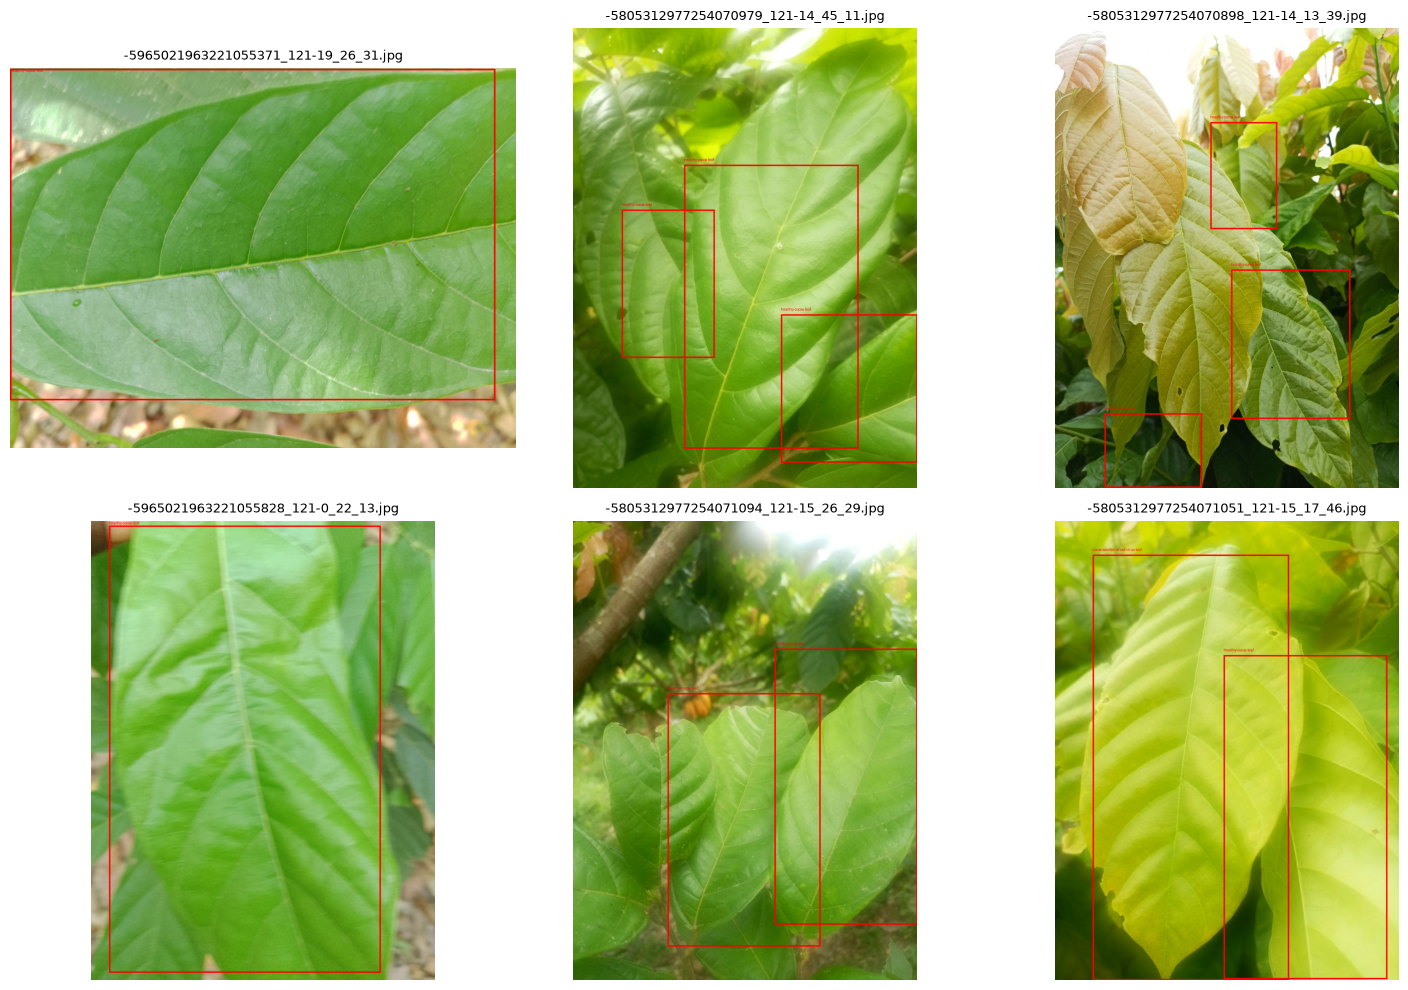

In [17]:
from pathlib import Path
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw, ImageFont
import math
import random
import matplotlib.pyplot as plt

project_dir = Path("/home/l2e_ayd/cocoa_research")
raw_dir = project_dir / "data/raw/karaagroai"

# --------------------------------------------------
# Find the mixed/CSSVD image
# --------------------------------------------------

mixed_image = None

for xml_file in raw_dir.rglob("*.xml"):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    labels = [
        obj.findtext("name", "").strip()
        for obj in root.findall("object")
    ]

    if "cocoa-swollen-shoot-virus-leaf" in labels:
        mixed_image = xml_file.with_suffix(".jpg")
        break


# --------------------------------------------------
# Select 5 random healthy images + mixed image
# --------------------------------------------------

all_images = sorted(raw_dir.rglob("*.jpg"))

healthy_candidates = [
    img for img in all_images
    if img != mixed_image
]

random.seed(42)
sample_images = random.sample(healthy_candidates, 5)

if mixed_image:
    sample_images.append(mixed_image)


# --------------------------------------------------
# Draw annotations
# --------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10)
)

axes = axes.flatten()

for ax, image_file in zip(axes, sample_images):

    image = Image.open(image_file).convert("RGB")
    draw = ImageDraw.Draw(image)

    xml_file = image_file.with_suffix(".xml")

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):

        label = obj.findtext("name", "").strip()

        bbox = obj.find("bndbox")

        xmin = int(bbox.findtext("xmin"))
        ymin = int(bbox.findtext("ymin"))
        xmax = int(bbox.findtext("xmax"))
        ymax = int(bbox.findtext("ymax"))

        draw.rectangle(
            [xmin, ymin, xmax, ymax],
            outline="red",
            width=4
        )

        draw.text(
            (xmin, max(0, ymin - 20)),
            label,
            fill="red"
        )

    ax.imshow(image)
    ax.set_title(image_file.name, fontsize=9)
    ax.axis("off")


# Hide unused axes
for ax in axes[len(sample_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()